### 🗂️ PROYECTO INTEGRADOR MODULO 4 - AVANCE 1         

### 🔎 CONTEXTO       
Tenemos nuestro socio FinanceGuard, quien es un banco digital que ha experimentado un crecimiento exponencial en los últimos años, alcanzando  10000 clientes activos. Sin embargo, la dirección ha detectado un incremento preocupante en la tasa de abandono de clientes (churn), que actualmente alcanza el 20% anual, resultando en pérdidas millonarias.

### 🎯 OBJETIVO   
Desarrollaremos un modelo de Machine Learning completo que prediga qué clientes tienen mayor probabilidad de abandonar el banco. Este modelo permitirá al equipo de retención implementar estrategias personalizadas para retener a los clientes en riesgo, con el objetivo de reducir el churn al 15%. Esto se realizará en 4 Avances independientes. Siendo éste el primer avance, donde realizaremos un modelo basado en regresión logística, con sus respectivos analisis.

**Solicitudes del Avance 1 - Modelo Regresión Logística**
- Investigar qué es el churn bancario.
- Carga y exploración inicial del dataset (incluye descarga de las librerias que se requieran para este avance).
- Realizar el EDA (esto incluye en la limpieza de datos nulos, eliminación de datos duplicados, visualización de graficas que muestren el estado real de las columnas del Dataset).
- Visulizar estado de las clases (se refiere a **desbalanceo de clases**, por ejemplo, en este caso realizar un conteo de cuantos clientes permanecen activos y cuantos no).
- Identificación de multicolinealidad entre las variables independiente y la variable dependiente (variable a predecir). Este paso se realiza por lo general en la visualización de graficas en el EDA.
- Implementación Regresión Logística.
- **Definir variables:** tales como: variables demográficas (edad, género, ubicación, antigüedad, etc), variables financieras (saldo promedio, productos contratados, transacciones, etc), variable objetivo: churn (1 = abandonó, 0 = activo)
- Encoding de variables categóricas (One-Hot, Label Encoding)
- Split básico: train (80%), test (20%)
- Escalamiento de variables numéricas (StandardScaler)

**1- ¿Qué es el churn bancario?** 
Sabemos que es la tasa de cancelación o abandono que mide el porcentaje de clientes que cierran sus cuentas o dejan de usar los servicios de un banco en un tiempo dado.

**1.1- Algunos conceptos claves:**
- Tasa de abandono -> El porcentaje de usuarios perdidos frente al total inicial en un periodo.
- Churn voluntario -> Cuando el cliente se va por enojo, inconformidades, mejores beneficios, entre otros.
- Churn involuntario -> Cuando se pierde al usuario por fallas técnicas o faltas de pago.


**2- ¿Qué es regresión logística?** 
Es un algoritmo de aprendizaje automático supervisado que se usa para resolver problemas de clasificación, prediciendo la probabilidad de que un dato pertenezca a una categoría específica (por ejemplo: "sí/no", "0/1", "true/false" o "spam/no spam")

**2.1- PARA ESTE PROYECTO SE REALIZARÁ REGRESIÓN LOGÍSTICA SIMPLE**

- Uso de scikit-learn (un de las librerias estrellas para la creación e implementación de modelos de machine learning)
- Interpretación de la función sigmoide (función que transforma cualquier numero en un valor entre 0 y 1, proceso ***obligatorio*** para realizar los escalamientos de las diferentes variables y que ninguna tenga peso por encima de otra)
- Análisis de coeficientes: con interpretación de pesos/coeficientes (***importante:***En la ***regresión logística***, los coeficientes no se interpretan de forma directa como en la ***regresión lineal*** porque el modelo no predice el resultado final, sino la probabilidad de que ocurra un evento, es decir un valor entre 0 y 1, para una clara interpretación de pesos/coeficientes, es necesario realizar el ***Odds y Odds ratios***). 
- Odds ratios y su significado (recordemos que tenemos el Odds (conocida como oportunidad) que es la probabilidad de que el evento ocurra dividida entre la probabilidad de que no ocurra, y Odds Ratio que es la medición de cuánto cambia esa oportunidad cuando tu variable de entrada aumenta en una unidad)
- Intervalos de confianza (miden la incertidumbre o precisión de los coeficientes, es decir, los valores de los Odds Ratios calculados por el modelo)

    ***IMPORTANTE*** ❌ Si el intervalo incluye el 1 (ej. [0.85, 1.40]): La variable no es estadísticamente significativa. El modelo no está seguro de si la variable aumenta el riesgo, lo disminuye o no hace nada.

- Evaluación específica: conjunto de métricas diseñadas exclusivamente para medir qué tan bueno es un clasificador/modelo, una metrica estrella es por lo general ***Matriz de Confusión***. (Recordemos que la ***Curva ROC y AUC, Precision, Recall, F1-Score*** son diferentes formas de medir, resumir o graficar lo que ocurre dentro de la Matriz de Confusión, que dependiendo del caso, se visualiza de manera más clara, y especifica la información necesaria)

### 🚀 IMPORTACIÓN DE LIBRERIAS Y 🔄️ CARGA DEL DATASET

In [5]:
import pandas as pd                     # Para manejo y limpieza de los DataFrame (el Dataset)
import numpy as np                      # Para realización de formulas matematicas
import seaborn as sns                   # Para mayor defición de mis graficas realizadas con Matplotlib
import matplotlib.pyplot as plt         # Para creación de graficas estructuradas con diferentes estilos
import warnings                         # Para la cancelación de mensajes de errores en la generación de graficas

import statsmodels.api as sm            # Para calcular los Intervalos de Confianza


from IPython.display import display     # Para mejor visualización del Dataset descargado en el DataFrame
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix #Para nuestra Matriz de Confusión

from sklearn.metrics import (
    accuracy_score,
    auc,
    classification_report,              # Para la Generación de todas nuestras Metricas Evaluadoras del Modelo
    f1_score,                           # Metricas como "Recall, Precision, F1-Score y Accuracy"
    precision_score,
    recall_score,
    roc_curve,
)

from sklearn.model_selection import train_test_split  # Para Split básico: train (80%), test (20%)
from sklearn.preprocessing import StandardScaler      # Para escalar valores numericas
from sklearn.preprocessing import LabelEncoder        # Para convertir valores categoricos a numeros o a BOOL
from sklearn.linear_model import LogisticRegression   # Para la creación e implementación de nuestro modelo de Regresión Logistica

warnings.filterwarnings('ignore')       # Para ignorar mensajes de "warning" en la realización de laas graficas

# Configuación base de mis graficos:
plt.style.use('seaborn-v0_8-whitegrid')   # Cuadrícula sutil de fondo
plt.rcParams.update({
    'figure.figsize': (10, 6),            # Tamaño estándar 
    'axes.titlesize': 14,                 # Tamaño de los titulos
    'axes.titleweight': 'bold',           # Titulos en negritas
    'axes.titlepad': 15                   # Ubicación del titulo para mayor visualización de la gráfica
})
# Selecciones del colores:
colors = ["#1B365D", "#4A90E2", "#95A5A6", "#9E1B32", "#E06666"]
sns.set_palette(sns.color_palette(colors))

print("Librerías descargadas con exito!🚀")


Librerías descargadas con exito!🚀


### ⚠️ INFORMACIÓN IMPORTANTE SOBRE EL DATASET:
Se visualiza que contamos con 10000 registros y un total de 14 columnas. Donde:

***Columnas sin relevancia en este caso para el modelo de predicción:***
- RowNumber	(Identificador interno de la tabla para clientes)
- CustomerId (Identificador interno del banco para clientes, éste suele ser una columna de clave primaria, y no debe de contener datos repetidos ni diplicados)	
- Surname (Nombre o/u Apellido del cliente)

***Columnas con tipo de dato numericos:***
- CreditScore (Record Crediticio, útil para saber que tan constante es un cliente en sus pagos de TC)	
- Age (Edad clientes)	
- Tenure (Años de entiguedad)
- Balance (Promedio de ingreso que se manejan en los productos que tiene el cliente con el banco - NO ESPECIFICA SI HACE REFERENCIA AL BALANCE EN CUENTAS BANCARIAS O TC)
- NumOfProducts	(Cantidad de productos (cuenta ahorro - corriente - tarjetas de creditos, etc) que maneja cada cliente)
- HasCrCard	(Siendo 0 = si tiene tarjeta de credito, 1= no tiene tarjeta de credito)
- IsActiveMember (Siendo 0 = si tiene membresía, 1= no tiene membresía)	
- EstimatedSalary (Salario estimdo)	
- ***Exited (Siendo 0 = cliente, 1= cliente churn) NUESTRA VARIABLE A PREDECIR***

***Columnas con tipo de datos categoricos:***
- Geography	(Pais donde se encuentra el cliente)
- Gender (Sexo del cliente)

In [6]:
# Carga del Dataset y confirmación de los datos se encuentren bien:
df = pd.read_csv("../data/Churn_Modelling.csv") 

print(f"🔄️ Cargando Dataset...\n")
print(f"Cantidad de registros: {df.shape[0]}, Cantidad de columnas: {df.shape[1]}\n")
print(f"{df.info()}\n")
display(df.head())

🔄️ Cargando Dataset...

Cantidad de registros: 10000, Cantidad de columnas: 14

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB
None



,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


### 🧐 Análisis Exploratorio de Datos (EDA)

**El rango de edad** entre los clientes esta desde los 18 años y los 92.

**Columnas categóricas necesarias para el analisis:**

Geografia:
- France     5014
- Germany    2509
- Spain      2477

Genero:
- Male      5457
- Female    4543

**Rango de Score Crediticio:** en los clientes estan entre 350 y 850

**Rango de años de antiguedad en la compañía:** 0 y 10 años

**Promedio General del Balance en cuenta: 76,485.89**

**Cantidad de clientes que son miembros (0), no son miembros(1):** (IsActiveMember)
- No Miembro     5151
- Miembro        4849

**Cantidad de productos por clientes:** Recordemos que son solo 4 productos
- Un Producto:       5084
- Dos Producto:      4590
- Tres Producto:     266
- Cuatro Producto:   60

**Promedio General del Salario Estimado: 100,090.24**

**Cantidad de clientes no churn (0) / churn(1):**
- No churn    7963
- Churn    2037

### ❗IMPORTANTE
No se visualizan valores nulos ni duplicados, tampoco espacios en las filas del Dataset con espacios. comillas, valores erraticos como 9999999, o negativos.

In [7]:
#Revisando estado de mis datos en el dataset, no nulos, no duplicados, etc:
# Visualizando que no tenga valores duplicados:
duplicados = df.duplicated().sum() #Creando nueva variable para ver valores duplicados
print(f"{duplicados}\n")

# Contando cuando valores como NaN o None o Nulos (sin datos), tenemos por cada columna
print(f"Revisando valores nulos por columna:")
print(f"{df.isnull().sum()}\n") 

# Revisando que no hayan filas con espacios, y que esto a veces se detecta como si tuviera datos 
# Pero en realidad es un error.
for col in df.select_dtypes(include=['object']).columns:
    espacios =(df[col] == " ").sum() + (df[col] == "").sum() 
    print(f"Espacios vacios por columna:\n '{col}':{espacios}")

# Explicación del "FOR": Por cada columna de dato tipo string en mi DataFrame
# Cuenta cuantas filas tienen ingresado solo espacios

# -----------------------------------------------------------------------------------------------
# Detectando valores atipicos (-999, 999999999, etc)
with pd.option_context('display.float_format', '{:,.2f}'.format):
    display(df.describe())
print("🔴 Observaciones importantes:\n")
print(f"El rango de edades entre clientes: {df['Age'].min()} y {df['Age'].max()}")
print("-"*100)
print(f"Información en nuestras columnas categoricas: {df['Geography'].unique()}")
print(f"Información en nuestras columnas categoricas: {df['Gender'].unique()}")
print("-"*100)
print(f"Conteo clientes por país: {df['Geography'].value_counts(dropna=False)}")
print("-"*100)
print(f"Conteo clientes por genero: {df['Gender'].value_counts(dropna=False)}")
print("-"*100)
print(f"Rango de Score Crediticio: {df['CreditScore'].min()} y {df['CreditScore'].max()}")
print("-"*100)
print(f"Rango de años de antiguedad en la compañía: {df['Tenure'].min()} y {df['Tenure'].max()}")
print("-"*100)
print(f"Promedio General del Balance en cuenta: {df['Balance'].mean():,.2f}")
print("-"*100)
print(f"Cantidad de clientes que son miembros (0), no son miembros(1): {df['IsActiveMember'].value_counts()}")
print("-"*100)
print(f"Cantidad de productos por clientes: {df['NumOfProducts'].value_counts()}")
print("-"*100)
print(f"Promedio General del Salario Estimado: {df['EstimatedSalary'].mean():,.2f}")
print("-"*100)
print(f"Cantidad de clientes activos (0) / no activos(1): {df['Exited'].value_counts()}")
print("-"*100)

0

Revisando valores nulos por columna:
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Espacios vacios por columna:
 'Surname':0
Espacios vacios por columna:
 'Geography':0
Espacios vacios por columna:
 'Gender':0


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,"10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00"
mean,"5,000.50","15,690,940.57",650.53,38.92,5.01,"76,485.89",1.53,0.71,0.52,"100,090.24",0.20
std,"2,886.90","71,936.19",96.65,10.49,2.89,"62,397.41",0.58,0.46,0.50,"57,510.49",0.40
min,1.00,"15,565,701.00",350.00,18.00,0.00,0.00,1.00,0.00,0.00,11.58,0.00
25%,"2,500.75","15,628,528.25",584.00,32.00,3.00,0.00,1.00,0.00,0.00,"51,002.11",0.00
50%,"5,000.50","15,690,738.00",652.00,37.00,5.00,"97,198.54",1.00,1.00,1.00,"100,193.91",0.00
75%,"7,500.25","15,753,233.75",718.00,44.00,7.00,"127,644.24",2.00,1.00,1.00,"149,388.25",0.00
max,"10,000.00","15,815,690.00",850.00,92.00,10.00,"250,898.09",4.00,1.00,1.00,"199,992.48",1.00


🔴 Observaciones importantes:

El rango de edades entre clientes: 18 y 92
----------------------------------------------------------------------------------------------------
Información en nuestras columnas categoricas: <StringArray>
['France', 'Spain', 'Germany']
Length: 3, dtype: str
Información en nuestras columnas categoricas: <StringArray>
['Female', 'Male']
Length: 2, dtype: str
----------------------------------------------------------------------------------------------------
Conteo clientes por país: Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
Conteo clientes por genero: Gender
Male      5457
Female    4543
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
Rango de Score Crediticio: 350 y 850
-----------------------------------------------------------------------

Clientes que permanecen (No Churn):
 Cantidad:7,963
 Porcentaje:(79.63%)
Clientes que NO permanecen (Churn):
 Cantidad:2,037
 Porcentaje:(20.37%)


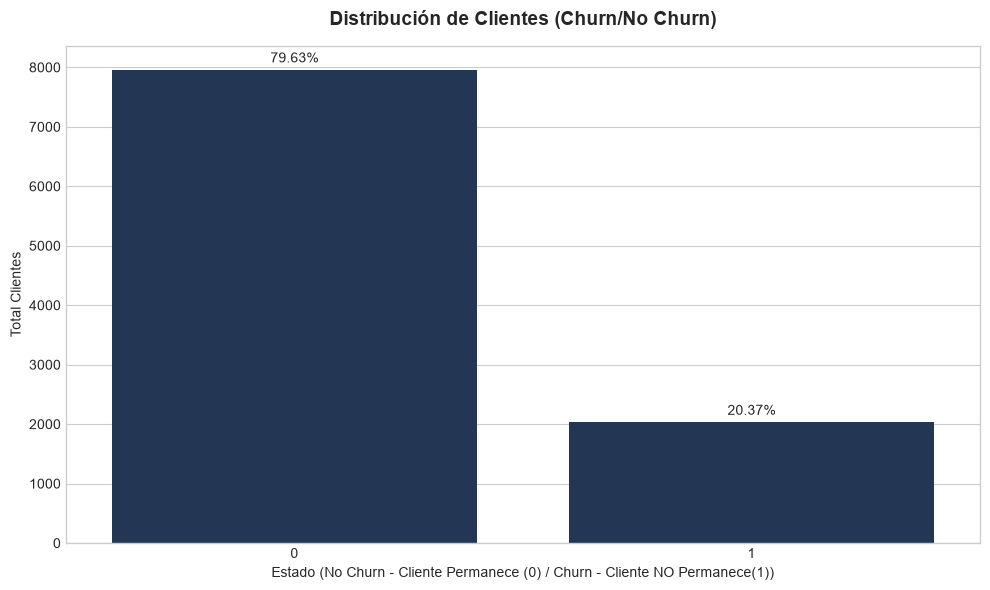

Análisis parcial de nuestros resultados en la gráfica de Barra:
Contamos con un Dataset DESBALANCEADO. Con un total de: 79.63% (No Churn)
A su vez nuestros casos positivos corresponden a: 20.37% (Churn)
Para el manejo de nuestros modelos de predicción tenemos que tomar en cuenta Metricas, tales como:
*Precision
*Recall
*F1
*Accuracy (solo para fines de prueba para éste proyecto, ya que no por si solo confiable en la predicción)


In [8]:
# PREPARANDO LOS DATOS PARA LAS DIVERSAS GRAFICAS QUE SE REQUIEREN PARA EL MODELO: 
# SE REALIZA UNA COPIA DEL DATA SET EN CASO DE QUE SE DEBA DE REALIZAR ALGUN MAPEO:
df_copy = df.copy()
clientes = df_copy['Exited'].value_counts() #Se cuentan cantidad de clientes Churn y no Churn
clientes_churn_porcentaje = df_copy['Exited'].value_counts(normalize=True) * 100 #Se saca porcentaje

# Se imprime la información exacta de los valores que queremos representar en graficos
print(f"Clientes que permanecen (No Churn):\n Cantidad:"
      f"{clientes[0]:,}\n Porcentaje:({clientes_churn_porcentaje[0]:.2f}%)")
print("="*100)
print(f"Clientes que NO permanecen (Churn):\n Cantidad:"
      f"{clientes[1]:,}\n Porcentaje:({clientes_churn_porcentaje[1]:.2f}%)")

# REALIZACIÓN DE GRAFICOS PARA EL ENTENDIMIENTO DE MI MODELO DE PREDICCIÓN:
columna_objetivo = 'Exited' #Definiendo mi columna objetivo, o base para mis graficos

# GRAFICA DISTRIBUCIÓN DE LA VARIABLE OBJETIVO (CHURN)
plt.figure()
ax = sns.countplot(data= df_copy, x= columna_objetivo)
plt.title ("Distribución de Clientes (Churn/No Churn)")
plt.xlabel ("Estado (No Churn - Cliente Permanece (0) / Churn - Cliente NO Permanece(1))")
plt.ylabel ("Total Clientes")

# PORCENTAJE SOBRE LAS BARRAS DE LA GRAFICA:
ax.bar_label(
    ax.containers[0],
    fmt= lambda x: f"{(x / len(df_copy)) * 100:.2f}%",
    padding=3,
)

plt.tight_layout()
plt.show()

print(f"Análisis parcial de nuestros resultados en la gráfica de Barra:")
print(f"Contamos con un Dataset DESBALANCEADO. Con un total de: {clientes_churn_porcentaje[0]:.2f}% (No Churn)")
print(f"A su vez nuestros casos positivos corresponden a: {clientes_churn_porcentaje[1]:.2f}% (Churn)")
print(f"""Para el manejo de nuestros modelos de predicción tenemos que tomar en cuenta Metricas, tales como:
*Precision
*Recall
*F1
*Accuracy (solo para fines de prueba para éste proyecto, ya que no por si solo confiable en la predicción)""")

### 📊 ANALISIS GRAFICAS EDA
Se realiza una copia del Dataset para manejo de todas las graficas, predicciones y modelo. 

***1. Grafico de Barra Clientes Churn / No Churn:***

- Clientes que permanecen (No Churn): 
**Porcentaje:(79.63%)**

- Clientes que NO permanecen (Churn): 
**Porcentaje:(20.37%)**

##### ------------------------------------------------------------

***2. Grafico de Violin para Variables Predecibles Categoricas***

- Age (Años - Diferencia Significativa):
**Churn:** Presenta una distribución desplazada hacia edades más altas (mediana alrededor de los 45 años).
**No Churn:** Los clientes que se quedan son más jóvenes (mediana cerca de los 35-36 años).

- Balance (Dinero en Cuenta - Efecto de Saldo Cero y Mayor Concentración):
En ambos grupos hay una masa de clientes con saldo cero. 
**Pero, clientes Churn:** la densidad de clientes con saldos medios y altos (alrededor de 100,000 - 120,000) es sensiblemente mayor.

- Tenure (Antigüedad)
**Churn / No Churn:** La antigüedad se distribuye de manera muy uniforme en ambos grupos (de 0 a 10 años).

- CreditScore (Puntaje de Crédito):
**Churn / No Churn:** Presenta formas y medianas casi idénticas (alrededor de 650 puntos).

- EstimatedSalary (Salario Promedio Anual):
**Churn / No Churn:** La distribución es plana y uniforme en ambos casos, abarcando desde 0 hasta más de 200,000.

##### ------------------------------------------------------------

***3. Grafico Barplot (Multiple Grafico de Barra) para Variables Predecibles Numericas***

- NumOfProducts (Número de Productos - Efecto más Drástico 🚨):
**No Churn:** 2 productos es el punto óptimo con menor churn (7.6%).
**Churn:** Tener 3 productos dispara el riesgo al 82.7%, y con 4 productos la tasa de abandono es del 100%. 

- Geography (Geografía):
**Alemania (Germany)** duplica el riesgo de abandono (32.4%) en comparación con Francia (16.2%) y España (16.7%).

- Gender (Género):
**Las mujeres (Female)** registran una tasa de fuga mayor (25.1%) frente a los **hombres (Male)** con 16.5%.

- Variables Binarias Inferiores (Miembro Activo - IsActiveMember / Tarjeta de Crédito - HasCrCard):
**IsActiveMember** muestra que los clientes inactivos son churn significativamente más (26.9%) que los activos (14.3%).

**HasCrCard** muestra tasas prácticamente idénticas (20.8% vs 20.2%), indicando que esa variable no genera diferenciación.

##### ------------------------------------------------------------

***4. Grafico Matriz de Correlacción***

- Principales Correlaciones con el Churn (Exited):

**Age (0.29):** Es la correlación positiva más fuerte de la tabla. A mayor edad del cliente, mayor es la probabilidad de churn.

**IsActiveMember (-0.16):** Muestra una relación negativa moderada. Los clientes activos tienen menor propensión al churn.

**Balance (0.12):** Existe una ligera relación positiva; clientes con saldos más altos tienden a mostrar un mayor riesgo relativo de churn.

***Multicolinealidad Fuerte entre Variables Independientes:***

**Balance vs NumOfProducts (-0.30):** Existe una correlación negativa moderada. Los clientes que tienen un mayor número de productos contratados tienden a registrar saldos promedio más bajos en sus cuentas (o viceversa).

***Variables Sin Correlación Significativa:***

**CreditScore (-0.03), Tenure (-0.01), HasCrCard (-0.01) y EstimatedSalary (0.01)** presentan valores prácticamente iguales a cero, indicando que no existe una relación lineal directa entre ellas y la variable de churn.

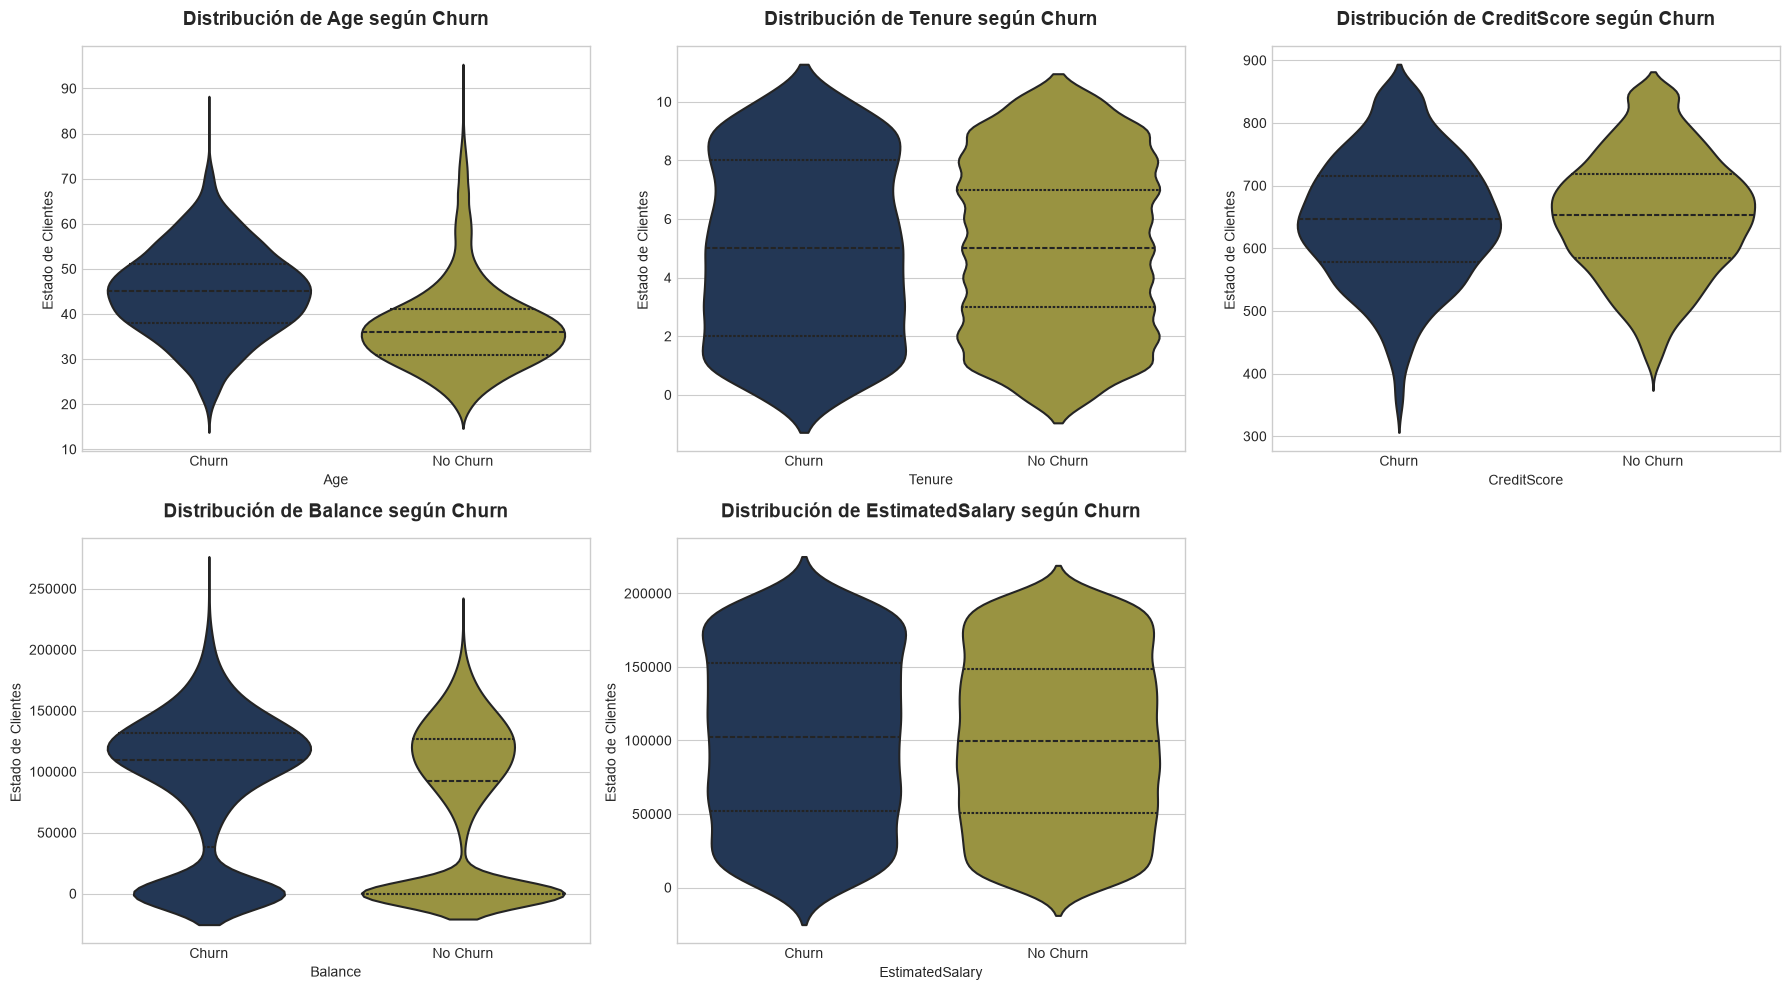

Se realizó 5 graficas base para poder detectar patrones de conducta en nuestros clientes Churn, en el rango de edades de
nuestros clientes, tenemos que entre 20 años a 60 años, con un mayor pico en los 45 años (aproximadamente) con un alto indice de 
clientes Churn

No se visualiza relación entre los años de antiguedad y los clientes churn

Tenemos un comportamiento similar para para clientes Churn y No Churn en nuestros datos de Record Crediticio y Salario Estimado

Finalmente, en el caso de Balance, contamos con un comportamiento atipico, donde clientes desde 0 euros en Balance son Churn 
hasta 200.000 euros, sin embargo la frecuencia disminuye entre 25.000 hasta 55.000 euros con mayor pico en 125.000 euros también son Churn


In [9]:
# Grafica Violin, para visualizar mis graficas con estructura estadistica y a su vez con la curva KDE (densidad)
# Mapeo de mi columna objetivo para cambiar la información de mis leyendas en las graficas:

df_copy["Churn_Label"] = df_copy[columna_objetivo].map({0:"No Churn", 1:"Churn"}) 
columnas_df = ["Age", "Tenure", "CreditScore", "Balance", "EstimatedSalary"] # Selecciono columnas numericas con diversidades en sus variables

# Recordemos que ya se han realizado los parametros bases de las graficas la inicio de ésta NoteBook
# Configuro el grid realizando una matriz de 5 graficos, 3 por columnas 2 por filas (2 x 3):
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(columnas_df):
  sns.violinplot(
      data=df_copy, # Uso del Dataframe copia (Para no realizar cambios en el Dataframe original)
      x="Churn_Label", # titulos Eje X
      y=col, # titulo Eje Y
      inner="quartile",
      linewidth=1.5, # Lineas gruesas (Mas de lo usual)
      palette=["#1B365D", "#A8A032"],
      ax=axes[i],
  )
  axes[i].set_title(f"Distribución de {col} según Churn")
  axes[i].set_ylabel("Estado de Clientes ")
  axes[i].set_xlabel(col)

axes[-1].axis("off") # Quito la ultima grafica vacia 
plt.tight_layout()
plt.show()

# Analisis parcial de las graficas:
# Contamos con 5 graficas base, tomando las columnas como: Edad, Tiempo de Antiguedad, Credit Score, Balance y Salario Estimado.
# Como no se visualizan grandes cambios o diferencias notables, se realizará una grafica más detallada
# Para las columnas numericas no discretas
print("""Se realizó 5 graficas base para poder detectar patrones de conducta en nuestros clientes Churn, en el rango de edades de
nuestros clientes, tenemos que entre 20 años a 60 años, con un mayor pico en los 45 años (aproximadamente) con un alto indice de 
clientes Churn""")
print("\nNo se visualiza relación entre los años de antiguedad y los clientes churn")
print("\nTenemos un comportamiento similar para para clientes Churn y No Churn en nuestros datos de Record Crediticio y Salario Estimado")
print("""\nFinalmente, en el caso de Balance, contamos con un comportamiento atipico, donde clientes desde 0 euros en Balance son Churn 
hasta 200.000 euros, sin embargo la frecuencia disminuye entre 25.000 hasta 55.000 euros con mayor pico en 125.000 euros también son Churn""")

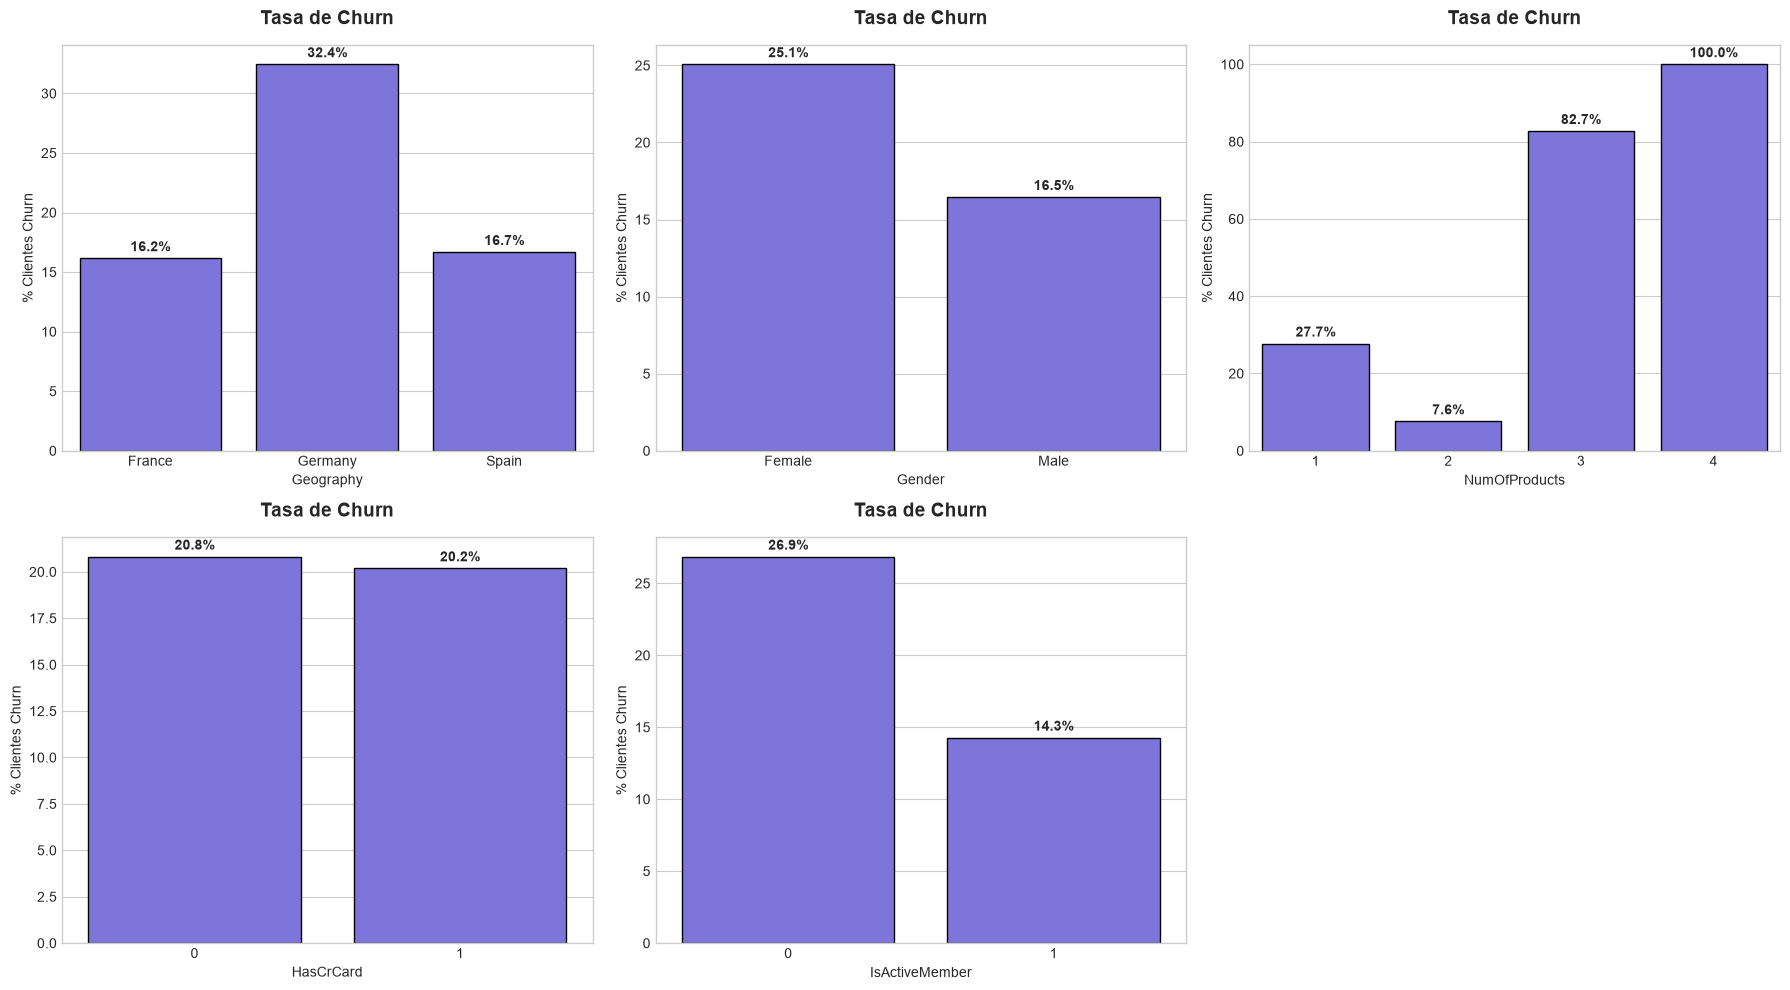

🔎 Análisis esperadas en las graficas:
🟩 Geography:
 - Mayor porcentaje de Churn: 'Germany' con 32.44%
 - Menor porcentaje de Churn: 'France' con 16.2%
🟩 Gender:
 - Mayor porcentaje de Churn: 'Female' con 25.07%
 - Menor porcentaje de Churn: 'Male' con 16.5%
🟩 NumOfProducts:
 - Mayor porcentaje de Churn: '4' con 100.00%
 - Menor porcentaje de Churn: '2' con 7.6%
🟩 HasCrCard:
 - Mayor porcentaje de Churn: '0' con 20.81%
 - Menor porcentaje de Churn: '1' con 20.2%
🟩 IsActiveMember:
 - Mayor porcentaje de Churn: '0' con 26.85%
 - Menor porcentaje de Churn: '1' con 14.3%
ANÁLISIS IMPORTANTE SOBRE NUESTRAS NUEVAS GRAFICAS:
---------------------------------------------------------------------------------------------------- 
Geography:
  - ❗ Germany: con 32.44% de mayor churn.
  (Mientras que France y Spain se mantienen dentro del umbral 15%)
  ✴️ Hallazgo: nos permitiria pensar que el país de residencia puede ser una constante relevante para el modelo
-----------------------------------------

In [10]:
# Manejo de Graficas para profundizar detalles:
columnas_graf_df = ["Geography", "Gender", "NumOfProducts", "HasCrCard", "IsActiveMember"]

#Configurando la matriz de graficas que quiero, en este caso son solo 5 columnas del df, por lo que serán 2 filas y 3 columnas
fig, axes= plt.subplots(2, 3, figsize=(18, 10))
axes= axes.ravel() # Esta linea de codigo es para aplanar la grafica a una sola lista de una dimensión 

# Estoy agrupando y sacando promedio para las 5 graficas
for idx, colum in enumerate(columnas_graf_df):
    churn_ratio = (
        df_copy.groupby(colum, observed=False)['Exited'].mean().reset_index()
    )
    churn_ratio["porcentaje_churn"] = churn_ratio['Exited']*100

# Realizando la grafica con seaborn:
    ax= sns.barplot(
    data=churn_ratio,
    x=colum,
    y="porcentaje_churn",
    color='#7263eb',
    edgecolor="black",
    ax=axes[idx],
)

# Personalizo los titulos de las graficas:
    axes[idx].set_title(f"Tasa de Churn") #titulo de las Graficas
    axes[idx].set_xlabel(colum) #Titulo eje X
    axes[idx].set_ylabel("% Clientes Churn") #Titulo eje y
    axes[idx].tick_params(axis="x", rotation=0) # Aplicando parametros solo en el eje X ("axis="x"") - Rotacion de cero para que sea mas limpia

# Agregando porcentaje sobre las barras:
    ax.bar_label(ax.containers[0], fmt="%.1f%%", padding=3, fontweight="bold")

# Al ser una matriz de 2 x 3, tendremos un espacio adicional en la segunda fila, 3ra columna, por lo que la estoy ocultando
axes[-1].axis("off") 
plt.tight_layout()
plt.show()

print(f"🔎 Análisis esperadas en las graficas:")
for colum in columnas_graf_df:
    percenj= df_copy.groupby(colum, observed=False)['Exited'].mean()*100
    print(f"🟩 {colum}:")
    print(f" - Mayor porcentaje de Churn: '{percenj.idxmax()}' con {percenj.max():.2f}%")
    print(f" - Menor porcentaje de Churn: '{percenj.idxmin()}' con {percenj.min():.1f}%")

print(f"""ANÁLISIS IMPORTANTE SOBRE NUESTRAS NUEVAS GRAFICAS:
{"-" *100} 
Geography:
  - ❗ Germany: con 32.44% de mayor churn.
  (Mientras que France y Spain se mantienen dentro del umbral 15%)
  ✴️ Hallazgo: nos permitiria pensar que el país de residencia puede ser una constante relevante para el modelo
{"-"*100}
Gender:
  - ❗ Female: con 25.07% de mayor churn.
  (Diferencia NOTORIA con genero Marculino, quien tiene 16.5%)
  ✴️ Hallazgo: en un análisis de comportamiento del mercado con enfasis en el genero, es una información relevante. 
  En el caso de un modelo de predicción, podría tomar en cuenta churn genero femenino.
{"-"*100}
NumOfProducts:
  - ❗⚠️  4 Productos: con 100.00% de mayor churn.  📌 PORCENTAJE CRITICO
  - ❗⚠️  3 Productos: con 82,7% de mayor churn.  📌 PORCENTAJE ALTO
  (1 producto = 27.7%, 2 producto= 7.7%)
  ✴️ Hallazgo: información muy importante, ya que mientras mayor cantidad de productos (recordemos que nuestro socio 
  cuenta con 4 productos en cartera actualmente), el porcentaje de churn es practicamente seguro. 
{"-"*100}
IsActiveMember:
  - ❗ No es miembro: con 26.85% de mayor churn.
  (Para nuestros clientes que si son miembros el porcentaje de churn es de 14.3%)
  ✴️ Hallazgo: se visualiza un alto indice de clientes que no son miembros y que si con churn. 
  Lo que sugiere que con una campaña de marketing supervisada para clientes no miembros, podria disminuir el porcentaje de churn.
{"-"*100}
HasCrCard:
  - ❗ NO HAY DIFERENCIA RELEVANTE.
   Contamos con porcentajes muy similares para clientes que si tienen tarjetas de credito (20.2%).
   Clientes que no tienen tarjeta de credito (20.81%)""")

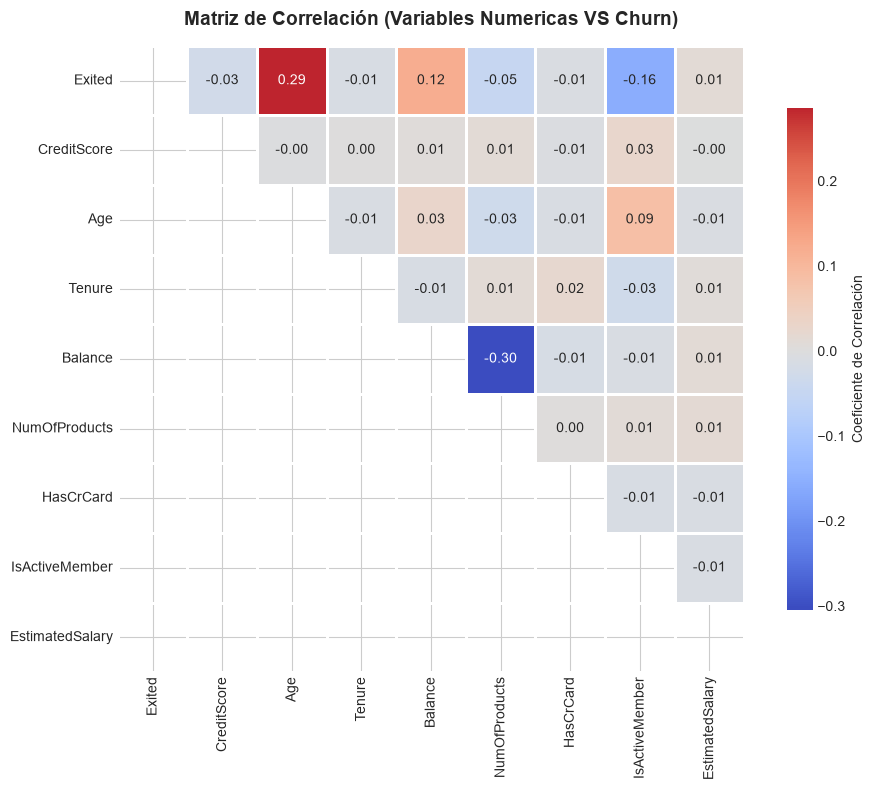

Matriz de Correlacion - Análisis
Age                0.285323
IsActiveMember    -0.156128
Balance            0.118533
NumOfProducts     -0.047820
CreditScore       -0.027094
Tenure            -0.014001
EstimatedSalary    0.012097
HasCrCard         -0.007138
Name: Exited, dtype: float64

1- Correlacion entre edad y churn, dando entender que mientras mayor edaad, mayor probabilidad de churn
2- Correlación en si el cliente es miembro, reduce la probabilidad de churn
3- Correlación en Balnce, dando a entender que mientras mas balance en cuenta, mayor probabilidad de churn

Para el resto de nuestros atributos, no se visualiza correlación significativa
----------------------------------------------------------------------------------------------------

Visualizando Multicolinealidad entre mis variables predictoras:

Como se visualiza en mi matriz de correlación, hay una relación entre Balance y Numeros de Producto.
No obstante, visualizaremos si existe multicolinealidad usando una funciómn FO

In [11]:
# GRAFICA FINAL DEL EDA - MATRIZ DE CORRELACIÓN:

# Selecciono mis columnas a correlacionar
corr_columnas = ["Exited",
                 "CreditScore", 
                 "Age", 
                 "Tenure", 
                 "Balance", 
                 "NumOfProducts", 
                 "HasCrCard", 
                 "IsActiveMember", 
                 "EstimatedSalary"]

# Correlaciono las columnas, usando siempre la copia del dataframe realizado en un principio:
corr_matriz = df_copy[corr_columnas].corr()

# Creo una mascara para que solo me muestre una parte del triangulo:
mascara = np.tril(np.ones_like(corr_matriz,dtype=bool))

# Configurando el tamaño de la grafica:
plt.figure(figsize=(10, 8))

# Graficando con Heatmap:
sns.heatmap(
    corr_matriz, # Selecciono variable donde hice la correlación
    mask=mascara, # Selecciono la marcara para que solo muestre una cara del tringulo
    annot=True, # Esto es para que muestre los valores dentro de cada cuadro
    fmt=".2f", # Solo quiero hasta 2 decimales
    cmap="coolwarm", # Tipo de color para la grafica
    center=0,
    square=True,
    linewidths=0.8,
    cbar_kws={"shrink": 0.8, "label": "Coeficiente de Correlación"}, # Modifico el tamaño de la barra a que sea mas pequeño
)

# Configuro titulos:
plt.title("Matriz de Correlación (Variables Numericas VS Churn)",
        fontsize=14,
        pad=15,
        fontweight="bold",
)
plt.tight_layout()
plt.show()
# Análisis de nuestra Matriz de Correlacion:
print("Matriz de Correlacion - Análisis")
matriz_correlacion= corr_matriz['Exited'].drop('Exited') # Se elimina la columna columna "Exited", nuestra columna a predecir
print(matriz_correlacion.sort_values(ascending=False, key=abs)) # Se ordena de mayor a menor.

print(f"\n1- Correlacion entre edad y churn, dando entender que mientras mayor edaad, mayor probabilidad de churn")
print(f"2- Correlación en si el cliente es miembro, reduce la probabilidad de churn")
print(f"3- Correlación en Balnce, dando a entender que mientras mas balance en cuenta, mayor probabilidad de churn")
print(f"\nPara el resto de nuestros atributos, no se visualiza correlación significativa")
print("-"*100)
print(f"\nVisualizando Multicolinealidad entre mis variables predictoras:")
print(f"""\nComo se visualiza en mi matriz de correlación, hay una relación entre Balance y Numeros de Producto.
No obstante, visualizaremos si existe multicolinealidad usando una funciómn FOR: """)

var_predictoras = corr_matriz.drop(index="Exited", columns="Exited")

# Definiendo el umbral:
umbral= 0.70

# Generando condiciones para el bucle:
hay_multicolinealidad = False

# Uso del bucle for:
for fila in range(len(var_predictoras.columns)):
    for f in range(fila + 1, len(var_predictoras.columns)):
        variable1= var_predictoras.columns[fila]
        variable2= var_predictoras.columns[f]
        valor_corr = var_predictoras.iloc[fila, f]

        if abs(valor_corr) >= umbral:
            print(f"Alta correlación entre {variable1} y {variable2} con un valor de: {valor_corr:.2f}")
            hay_multicolinealidad=True

if not hay_multicolinealidad:
    print (f"✅ ¡Todo bien! No hay multicolinealidad")

### ▶️ INICIO DE REGRESIÓN LOGÍSTICA

✅ Se realiza la limpieza de los datos, eliminando las columnas innecesarias para el modelo, todo desde la copia de un Dataframe.
➡️Columnas Eliminadas: "RowNumber", "CustomerId", "Surname","Churn_Label"

✅ Se codificó Variables Categoricas: "Gender" y "Geography".
➡️Usando label_encoding para cambiar a variable categoricas (Gender) a numerica entre 1 y 0 (aplica para variables unicamente con 2 valores unicos)
📌Valores asignados por Python para Female: 0
📌Valores asignados por Python para Male: 1

➡️Usaremos one hot-encoding para cambiar variables categoricas (Geography) a booleanas, creando una columna por cada Categoria en nuestra variable categorica (Alemania - Fracia - España), eliminando una de las columnas para no tener valores redundantes.

➡️Se concatenará las 2 columnaas resultantes de one hot-encoding.

➡️Se eliminó la columna (Geography)

Ahora nuestro Dataset cuenta con un total de: 11 columnas y la mismaa cantidad de row (10.000)


In [12]:
# Luego de la realización de los graficos, tenemos un preambulo de los datos y una idea de nuevas variables predictoras
# Tambien pudimos visualizar que no hay Multicolinealidad, por lo que no tendremos problemas al momento de implementar
# El modelo de Regresión Logistica.
# Para empezar, los datos ya estan limpiados, por ahora solo eliminaremos las columnas que no necesitaremos.

columnas_eliminadas = ["RowNumber", "CustomerId", "Surname","Churn_Label"] # Columnas a Eliminar
df_copy = df_copy.drop(columns=columnas_eliminadas) # Eliminando columnas en el df_copy
print(f"✅ Columnas eliminadas correctamente:") 
display(df_copy.head())

# Codificando Variables categoricas:
# Usaremos label_encoding enconding para cambiar a variable numerica entre 1 y 0 a variables categoricas solo con 2 diferentes valores
# Usaremos one hot-encoding para cambiar variables categoricas a booleanas:
# Confirmando valores categoricas en nuestras columnas

print(f"Valores unicos en la columna Genero: {df_copy['Gender'].unique()}")
print("-"*100)
print(f"Valores unicos en la columna Pais: {df_copy['Geography'].unique()}")

# Aplicamos Label Encoding para Gender ya que tenemmos solo 2 variables categoricas:
print(f"\nRealizando la codificación para Gender...")
encoding_label = LabelEncoder()
df_copy['Gender'] = encoding_label.fit_transform(df_copy['Gender'])

# Confirmamos que si se hizo la conversión:
print(f"✅ Nuevos valores codificados: {df_copy['Gender'].unique()}")

# Forzamos a Python nos indique a quien le asigno el 0 y a quien el 1:
print(f" {dict(zip(encoding_label.classes_,encoding_label.transform(encoding_label.classes_)))}")

# Realizamos el one-hot encoding para nuestra columna "Geography", ya que tiene 3 valores diferentes:
print(f"\nRealizando la codificación de Geography, con One Hot-Encoding...")
codificando_pais = pd.get_dummies(df_copy['Geography'], prefix='Geography', drop_first=True) #Eliminamos una de las columnas para no generar información redundate, se sabrá que si en 2 paises es "False", entonces por descarte es el otro
print(f"Confirmando nuevas columnas: {list(codificando_pais.columns)}")

# Concatenando mis nuevas columnas a mi df_copy:
df_copy = pd.concat([df_copy,codificando_pais], axis=1)
df_copy = df_copy.drop('Geography', axis=1)

print(f"\n ✅ Codificación realizada con exito")
display(df_copy.head())

✅ Columnas eliminadas correctamente:


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


Valores unicos en la columna Genero: <StringArray>
['Female', 'Male']
Length: 2, dtype: str
----------------------------------------------------------------------------------------------------
Valores unicos en la columna Pais: <StringArray>
['France', 'Spain', 'Germany']
Length: 3, dtype: str

Realizando la codificación para Gender...
✅ Nuevos valores codificados: [0 1]
 {'Female': np.int64(0), 'Male': np.int64(1)}

Realizando la codificación de Geography, con One Hot-Encoding...
Confirmando nuevas columnas: ['Geography_Germany', 'Geography_Spain']

 ✅ Codificación realizada con exito


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True


### ▶️ REGRESIÓN LOGÍSTICA - PARTE 2

✅ Se realizó la serapación de los Features de mis variables predictoras:
['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain']

✅ Se realizó laa separación de mi variable a predecir:
Exited

✅ Se confirma que los valores en nuestros row (filas) se mantienen en:
NoChurn:    7963
Churn:      2037


In [13]:
# Separando Features y Target (Separando mis variables predictoras y mi variable a predecir)
x = df_copy.drop('Exited', axis=1)
y = df_copy['Exited']

print(f"Confirmando separación de variables y mi Target se realizó con exito:")
print(f"\nLista de columnas en mi variable x: \n{list(x.columns)}")
print(f"\nNombre de mi variable y: {y.name} \nTotal de valores en mi variable a predecir (y): {y.value_counts()}")

Confirmando separación de variables y mi Target se realizó con exito:

Lista de columnas en mi variable x: 
['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain']

Nombre de mi variable y: Exited 
Total de valores en mi variable a predecir (y): Exited
0    7963
1    2037
Name: count, dtype: int64


### ▶️ REGRESIÓN LOGÍSTICA - PARTE 3

✅ Se realiza la división correcta de los datos:
80% Datos de entrenamiento y 20% Datos de Test. Usando "train_test_split" de la libreria: skleanr

✅ Se confirma que la información fue dividida correctamente:
x_train es igual a: (8000, 11) (11 se refiere a la cantidad de features)
y_train es igual a: (8000,)

----------------------------------------------------------------------------------------------------

y_test es igual a: (2000,)
x_test es igual a: (2000, 11)

✅ Visualizamos que el porcentaje fue proporcional a clases (es decir, 80% No Churn, 20% Churn)
Porcentaje churn en y_train: 
NoChurn    79.625%
Churn      20.375%

----------------------------------------------------------------------------------------------------

Porcentaje churn en y_test: 
NoChurn    79.65%
Churn      20.35%

✅ Se utiliza la estrategia: 
random_state=42, -> Para maantener reproducibilidad

✅ Se utiliza la estrategia: 
stratify=y, -> Para mantener proporciónd de clase

✅ Se escala todas las variables usando el metodo:
StandardScaler y .fit() -> Se escalan solo datos de entrenamiento porque nuestra variable a predecir ya tiene los valores entre 0 y 1

Una vez escalados se transforman los datos con el metodo: scaler.transform, y, como pierden el formato de Dataframe, se convierten nuevamente en un Dataframe con el metodo pd.DataFrame

In [14]:
# Realizando división de mis datos para el modelo de regresión logistica:
# La división se realizará 80% Datos de entrenamiento y 20% Datos de Test:
# Finalmente usaré stratify=y para mantener la proporción de churn en ambos set.

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,      # 20% para test
    random_state=42,     # Reproducibilidad (mantener los mismos tipos de datos independientemente de cuantas veces se entrene el modelo)
    stratify=y          # Para mantener proporciónd de clase
)

# Confirmando que se realizó la división de forma correcta:
print(f"Validando estado de la división:")
print(f"\nx_train es igual a: {x_train.shape}")
print(f"y_train es igual a: {y_train.shape}")
print("-"*100)
print(f"y_test es igual a: {y_test.shape}")
print(f"x_test es igual a: {x_test.shape}")
print("-"*100)
print(f"\nPorcentaje churn en y_train: \n{y_train.value_counts(normalize=True) * 100}")
print(f"\nPorcentaje churn en y_test: \n{y_test.value_counts(normalize=True) * 100}")


# Escalando Variables numericas
# Recordemos que debemos escalar las variables numericas, para que ninguna con mayor valor "pise" a la de menor
# Por ende, todas son escaladas en un rango de 0 y 1.

scaler = StandardScaler ()
scaler.fit(x_train) # Se escala solo datos de entrenamiento porque nuestra Target ya tiene los valores entre 0 y 1

x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

#Preservo los índices y nombres de columnas: Al reconvertir las matrices de NumPy de nuevo a DataFrames 
x_train_scaled = pd.DataFrame(x_train_scaled, columns=x_train.columns, index=x_train.index)
x_test_scaled = pd.DataFrame(x_test_scaled, columns=x_test.columns, index=x_test.index)

print(f"Datos escaldos:") #Confirmando que los datos esten bien escalados y en DataFrame
print(x_train_scaled)

# Ahora que todas las variables estan escaladas
# Si podemos implemetar nuestro modelo
# MODELO DE REGRESIÓN LOGISTICA

modelo_rl = LogisticRegression(
    random_state= 42, 
    max_iter= 1000,   # Se aumenta conversiones para optimización de convergencia
    solver= 'lbfgs'   # Para mejorar el algoritmo de optimización
)

print(f"Entrenando Modelo de Regresión Logistica...")
modelo_rl.fit(x_train_scaled, y_train)

print(f"""\nInformación basica de nuestro modelo:
Algoritmo de Optimización {modelo_rl.solver}
Convergencia {modelo_rl.n_iter_[0]}
Coeficientes {len(modelo_rl.coef_[0])}""")

# Una vez tenemos nuestro modelo. tenemos que ver como esta constituido nuestro modelo y como estan influenciando las variables
coeficientes = pd.DataFrame({
    'Feature': x_train.columns,
    'Coeficiente': modelo_rl.coef_[0],
    'Coeficiente_Absoluto': np.abs(modelo_rl.coef_[0])

}).sort_values('Coeficiente_Absoluto', ascending = False)

print(f"Coeficientes de mi Modelo de Predición:")
print(f"\nSesgo/Intercepto: {modelo_rl.intercept_[0]:.4f}")
print(f"""\nRecordemos algunas reglas:
- Coeficiente positivo: aumenta la probabilidad de churn.
- Coeficiente negativo: disminuye la probabilidad de churn.""")

# Queriendo ver el sesgo/intercepto como un porcentaje (para tener mayor familiaridad con el valor de mi modelo)
prob_base = 1 / (1 + np.exp(-modelo_rl.intercept_[0])) # se usa -, para cambiar el signo y poder hacer la función sigmoide
# X=0 representa la media o el promedio de cada variable (feature) de mi modelo.
# prob_base en este caso representaria la probabilidad de churn de un cliente promedio en todas mis features 
print(f"\nProbabilidad base de Churn (con X=0): {prob_base * 100:.2f}%")

display(coeficientes)



Validando estado de la división:

x_train es igual a: (8000, 11)
y_train es igual a: (8000,)
----------------------------------------------------------------------------------------------------
y_test es igual a: (2000,)
x_test es igual a: (2000, 11)
----------------------------------------------------------------------------------------------------

Porcentaje churn en y_train: 
Exited
0    79.625
1    20.375
Name: proportion, dtype: float64

Porcentaje churn en y_test: 
Exited
0    79.65
1    20.35
Name: proportion, dtype: float64
Datos escaldos:
      CreditScore    Gender       Age    Tenure   Balance  NumOfProducts  \
2151     1.058568  0.907507  1.715086  0.684723 -1.226059      -0.910256   
8392     0.913626  0.907507 -0.659935 -0.696202  0.413288      -0.910256   
5006     1.079274 -1.101919 -0.184931 -1.731895  0.601687       0.808830   
4117    -0.929207  0.907507 -0.184931 -0.005739 -1.226059       0.808830   
7182     0.427035  0.907507  0.955079  0.339492  0.548318       0

,Feature,Coeficiente,Coeficiente_Absoluto
2,Age,0.738847,0.738847
7,IsActiveMember,-0.515485,0.515485
9,Geography_Germany,0.356679,0.356679
1,Gender,-0.260851,0.260851
4,Balance,0.160622,0.160622
0,CreditScore,-0.085986,0.085986
5,NumOfProducts,-0.070292,0.070292
8,EstimatedSalary,0.047725,0.047725
6,HasCrCard,-0.032208,0.032208
3,Tenure,-0.020071,0.020071


### ▶️ REGRESIÓN LOGÍSTICA - PARTE 4

✅ Finalmente se entrena el modelo usando el metodo: LogisticRegression (libreria skleanr). Y realizamos la emisión de los coeficientes para poder visualizar que variables tuvieron mayor peso en nuestro modelo.

***Explicación de mis coeficientes:***
***Variables con Alto:***
- Age (+0.7388): Es la variable con mayor peso positivo en todo el modelo. A mayor edad del cliente, se incrementa significativamente el riesgo de churn.

- IsActiveMember (-0.5155): Es el factor protector de mayor magnitud. Ser un miembro activo reduce fuertemente la probabilidad de churn.

- Geography_Germany (+0.3567): Residir en Alemania incrementa de forma notable la probabilidad de abandono frente a los otros países.

--------------------------------------------------------------------------------------------------------

***Variables con Impacto Moderado:***
- Gender (-0.2609): Muestra una relación negativa con el churn (asociada habitualmente a un menor riesgo en hombres dentro de este dataset codificado).

- Balance (+0.1606): Mantener un saldo mayor en la cuenta aumenta moderadamente el riesgo relativo de fuga.

--------------------------------------------------------------------------------------------------------

***Variables con Impacto Bajo:***
- EstimatedSalary (+0.0477): coeficiente absoluto muy cercanos a cero, indicando que aportan poca influencia directa a la predicción final.

- HasCrCard (-0.0322): coeficiente absoluto muy cercanos a cero, indicando que aportan poca influencia directa a la predicción final.

- Tenure (-0.0201): coeficiente absoluto muy cercanos a cero, indicando que aportan poca influencia directa a la predicción final.

- Geography_Spain (+0.0189): coeficiente absoluto muy cercanos a cero, indicando que aportan poca influencia directa a la predicción final.

### ▶️ REGRESIÓN LOGÍSTICA - PARTE 5

***REPRESENTACIÓN DE LA FUNCIÓN SIGMOIDE AJUSTADA A MIS DATOS A TRAVÉS DE UNA GRAFICA:***

Recordemos que la función sigmoide es la transformación de la combinación lineal de las variables en una probabilidad 
Acotada entre 0 y 1 ("0% a 100%"). El punto de corte predeterminado usualmente es 0.5 ("50%").

Realizamos la función sigmoide tomando en cuenta una sola variable como "Edad". Es importante mencionar que si bien se tomo como base la variable "Edad". De todos modos el modelo toma en cuenta el resto de las variables para la grafica.

Teniendo en cuenta que los resultados de mi grafica indica:
- A los 20-30 años: La línea rosada está por debajo del umbral (0.50). Esto significa que el modelo precide que éstas personas no son posibles churn.
- A los 50-60 años: La línea sube y cruza el umbral.
- A partir de los 50 años en adelante: La probabilidad supera el umbral, por lo que el modelo empieza a predecir que esos clientes se van a ir.

❗Resumen de mi grafica: A mayor edad, la probabilidad de churn se dispara. ***La función sigmoide*** captura esa tendencia ascendente. Al final (después de los 80 años) hay muy pocos clientes en el banco, por lo que la línea se vuelve un poco inestable por la falta de datos.

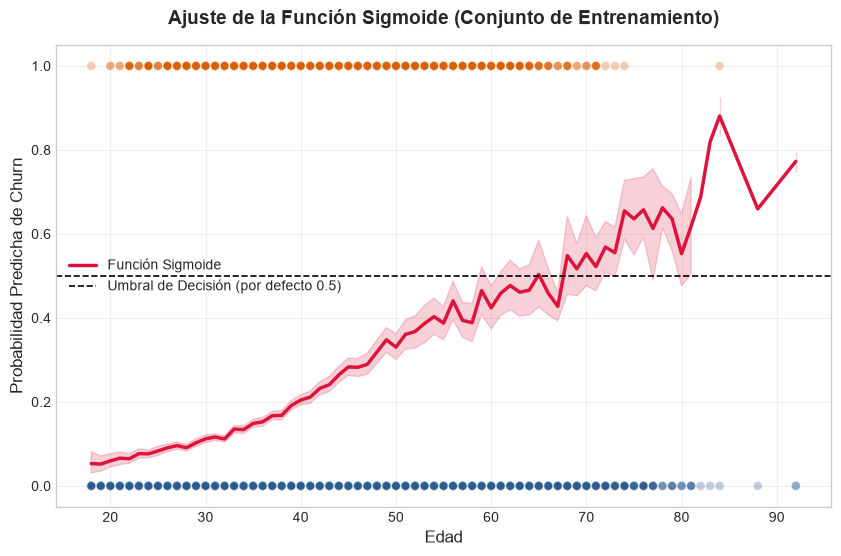


Puntos Azules en la parte inferior da referencia a (0): 
      - Son clientes que NO hicieron churn.
Puntos Naranjas en la parte superior (1): 
      - Son clientes que SÍ hicieron churn.
Línea Punteada (0.5): 
      - Es la frontera de decisión. Si la curva rosada está por debajo de esta línea, el modelo clasifica al cliente como "No Churn". 
      Si la supera, lo clasifica como "Churn".
Línea Rosada en zigzag (Nuestra Función Sigmoide): 
      - Muestra el promedio de probabilidad que el modelo le asigna a los clientes según su edad.

🚨CONCLUSIÓN (APLICA PARA LA VARIABLE PREDICTORA EDAD):
- A los 20-30 años: La línea rosada está por debajo del umbral (0.50). Esto significa que el modelo precide que éstas personas no son posibles churn.
- A los 50-60 años: La línea sube y cruza el umbral.
- A partir de los 50 años en adelante: La probabilidad supera el umbral, por lo que el modelo empieza a predecir que esos clientes se van a ir.

❗Resumen: A mayor edad, la probabilidad de churn se 

In [15]:

# Demostrando la función sigmoide tomando en cuenta una variable importante segun nuestros coeficientes (Edad)

# 1. Obtenemos únicamente las probabilidades continuas de Churn
# Usamos predict_proba en x_train_scaled
y_proba_train = modelo_rl.predict_proba(x_train_scaled)[:, 1]

# 2. Para graficar 'Age' sin perder la escala visual interpretable:
edad_train = x_train['Age']

# 3. Configuramos las graficas:
plt.Figure(figsize= (10, 6))

# Tomando los puntos reales del entrenamiento:
sns.scatterplot(
    x=edad_train,
    y=y_train,
    hue=y_train,
    palette={0: "#2b5c8f", 1: "#d95f02"}, # Asignando colores para 0 clientes que no se van, y 1 clientes que se van, segun modelo
    alpha=0.3,
    s=40,
    legend=False,

)

# Realizando la curva Sigmoide con datos predichos:
sns.lineplot(
    x=edad_train,
    y=y_proba_train,
    color="crimson",
    linewidth=2.5,
    label="Función Sigmoide",
)

plt.axhline(
    0.5,
    color="black", # Color de la linea
    linestyle="--", # Estilo de la linea
    linewidth=1.2,
    label="Umbral de Decisión (por defecto 0.5)",
)

plt.title(
    "Ajuste de la Función Sigmoide (Conjunto de Entrenamiento)",
    fontsize=14,
    pad=15,
    fontweight="bold",
)
plt.xlabel("Edad", fontsize=12)
plt.ylabel("Probabilidad Predicha de Churn", fontsize=12)
plt.ylim(-0.05, 1.05)
plt.grid(alpha=0.3)
plt.legend(loc="center left")

plt.show()

# Comprensión de nuestra grafica con la función sigmmoide en edad:

print(f"""\nPuntos Azules en la parte inferior da referencia a (0): 
      - Son clientes que NO hicieron churn.
Puntos Naranjas en la parte superior (1): 
      - Son clientes que SÍ hicieron churn.
Línea Punteada (0.5): 
      - Es la frontera de decisión. Si la curva rosada está por debajo de esta línea, el modelo clasifica al cliente como "No Churn". 
      Si la supera, lo clasifica como "Churn".
Línea Rosada en zigzag (Nuestra Función Sigmoide): 
      - Muestra el promedio de probabilidad que el modelo le asigna a los clientes según su edad.""")

print(f"""\n🚨CONCLUSIÓN (APLICA PARA LA VARIABLE PREDICTORA EDAD):
- A los 20-30 años: La línea rosada está por debajo del umbral (0.50). Esto significa que el modelo precide que éstas personas no son posibles churn.
- A los 50-60 años: La línea sube y cruza el umbral.
- A partir de los 50 años en adelante: La probabilidad supera el umbral, por lo que el modelo empieza a predecir que esos clientes se van a ir.

❗Resumen: A mayor edad, la probabilidad de churn se dispara. La función sigmoide captura esa tendencia ascendente
Al final (después de los 80 años) hay muy pocos clientes en el banco, por lo que la línea se vuelve un poco inestable por la falta de datos.
""")

### ▶️ REGRESIÓN LOGÍSTICA - PARTE 6

***CALCULO DE ODDS RATIOS***

PARA TENER MAYOR CLARIDAD EN LOS INTERVALOS DE CONFIANZA

Un breve recordatorio de lo que significan los terminos:
- Probabilidad: proporción de casos en los que ocurre un evento sobre el total de casos
- Coeficientes positivos: incrementan los log-odds de churn.
- Coeficientes negativos: actúan como factores de protección, reduciendo el riesgo de churn.
- Odds (Ventaja / Apuesta a favor): Es la razón entre la probabilidad de que algo ocurra versus la probabilidad de que no ocurra.
- Odds Ratio (OR): Es el cociente entre dos Odds. Compara cómo cambian los Odds al cambiar una variable. Es decir, mide el factor multiplicativo por el cual cambian las probabilidades (odds) de Churn por cada incremento unitario en la variable: 
(por ejemplo, comparar el Odds de Churn de un cliente mayor versus uno joven, o comparar hombres vs mujeres).

* OR = 1: La variable no influye en la probabilidad de Churn.
* OR > 1: La variable aumenta el riesgo de Churn. Por ejemplo, si el OR de "Age" es 1.07. 
    - Significa que por cada año adicional de edad, los odds de churn aumentan un 7%. Explicación:
            Formula matematica: (OR - 1 = 1.07 - 1 = 0.07).
* OR < 1: La variable es un factor protector (disminuye el riesgo).Por ejemplo, si el OR en "IsActiveMember" es 0.55
    - Significa que ser miembro activo reduce significativamente la probabilidad de irse.

***EXPLICACIÓN BREVE DE ODDS RATIOS (MAS ADELANTE SE EXPLICA DE FORMA MAS DETALLADA***

- ¿Que es el Odds Ratio? 

***Variables con mayor impacto:***
- Age: duplica el riesgo de churn por cada unidad con un 109.35% de impacto, con un Odds Ratio de 2.09.
- Geography_Germany: si reside en Alemania incrementa el riesgo de churn en un 42.86%.
- Balance: saldos más elevados se interpretan en un aumento del 17.42% en la propensión al churn.
- IsActiveMember: (si es si) reduce el riesgo de fuga en un 40.28% (Odds Ratio = 0.597).
- Gender: representa una disminución del riesgo de churn del 22.96%.


In [16]:
# Recordemos que ya hay una variable con los coeficientes, por lo que se utiliza aqui nuevamente:
coeficientes['Odds_Ratio'] = np.exp(coeficientes['Coeficiente'])

coeficientes['Impacto_Porcentual'] = (coeficientes['Odds_Ratio'] - 1) *100
coeficientes = coeficientes.sort_values(by='Odds_Ratio', ascending=False)

print("=== TABLA DE ODDS Y PORCENTAJE RATIOS DEL MODELO ===")
display(coeficientes)

=== TABLA DE ODDS Y PORCENTAJE RATIOS DEL MODELO ===


,Feature,Coeficiente,Coeficiente_Absoluto,Odds_Ratio,Impacto_Porcentual
2,Age,0.738847,0.738847,2.093520,109.351968
9,Geography_Germany,0.356679,0.356679,1.428578,42.857759
4,Balance,0.160622,0.160622,1.174241,17.424121
8,EstimatedSalary,0.047725,0.047725,1.048882,4.888247
10,Geography_Spain,0.018907,0.018907,1.019087,1.908700
3,Tenure,-0.020071,0.020071,0.980129,-1.987113
6,HasCrCard,-0.032208,0.032208,0.968306,-3.169444
5,NumOfProducts,-0.070292,0.070292,0.932122,-6.787808
0,CreditScore,-0.085986,0.085986,0.917607,-8.239334
1,Gender,-0.260851,0.260851,0.770396,-22.960431


### ▶️ REGRESIÓN LOGÍSTICA - PARTE 7

***INTERVALOS DE CONFIANZA:***

Breve resumen de que es lo que significa Intervalo de Confianza:

- ¿Que es IC_Lower_95%?
 * Límite inferior del intervalo de confianza
- ¿Que es IC_Upper_95%?
 * Límite superior del intervalo de confianza
Si el intervalo si incluye 0, no es significativo

***📌 Resumen de Insights: Intervalos de Confianza (IC al 95%)***
1. Robustez del Modelo y Significancia General
- 8 de las 11 variables analizadas son estadísticamente significativas (Significativo = True), lo que demuestra que el modelo está fundamentado en patrones reales y no en variaciones aleatorias de los datos.

2. Principales Factores Promotores del Churn (Riesgo Confirmado)
- Edad (Age): Es el predictor con mayor impacto. Su intervalo de confianza [+0.681, +0.798] es estrictamente positivo y está alejado del cero. Con un 95% de confianza, los Odds Ratio varían entre 1.97 y 2.22, lo que confirma que el riesgo de fuga se incrementa al menos en un 97% por cada aumento unitario en la escala de edad.
- Geografía (Geography_Germany): Presenta un IC de [+0.293, +0.421]. Confirma con alta certeza que residir en Alemania aumenta sustancialmente las probabilidades de churn respecto a la categoría base.
- Balance (Balance): Su intervalo de [+0.090, +0.231] reafirma que tener un saldo mayor en la cuenta incrementa de forma estadísticamente significativa la probabilidad de abandonar el banco.

3. Principales Factores Protectores de Churn (Retención Confirmada)
- Miembro Activo (IsActiveMember): Es el factor protector más potente. Su intervalo [-0.578, -0.453] es totalmente negativo, confirmando una reducción sólida de entre un 36% y 44% en los odds de churn para clientes activos.
- Género (Gender): Su intervalo [-0.320, -0.201] valida de forma robusta un menor riesgo de abandono en hombres que en mujeres.

4. Variables No Significativas (Ruido o Sin Efecto Real)
- Las variables Tenure, HasCrCard, EstimatedSalary y Geography_Spain tienen intervalos de confianza que incluyen el valor cero (ej. Tenure: [-0.079, +0.038]).
- Insight para el Negocio: No existe evidencia estadística suficiente al 95% de confianza para afirmar que poseer tarjeta de crédito, la antigüedad o el salario estimado influyan por sí solos en la decisión del cliente de quedarse o irse.



In [17]:
# 1. Agregamos el intercepto que requiere la libreria statsmodels:
x_train_sm = sm.add_constant(x_train_scaled)

# 2. Ajustamos el modelo de Regresión Logistica:
modelo_stats = sm.Logit(y_train,x_train_sm).fit(disp=False)

# 3. Obtenemos coeficientes e intervalos de confianza. 
# Error Estandar y Problabilidad de Cociente entre el coeficiente y su error estándar (prob_cociente)
resumen_ic = pd.DataFrame({
    'Variable': ['Intercepto'] + list(x_train.columns),
    'Coeficiente': modelo_stats.params.values,
    'Error_Estandar': modelo_stats.bse.values,
    'Prob_Cociente': modelo_stats.pvalues.values,
    'Odds_Ratio': np.exp(modelo_stats.params.values),
    'IC_Lower_95%': modelo_stats.conf_int()[0].values,
    'IC_Upper_95%': modelo_stats.conf_int()[1].values,

})

# 4. Evaluamos si el intervalo incluye el cero (Si incluye 0, no es significativo)
resumen_ic['Incluye_Cero'] = (resumen_ic['IC_Lower_95%'] <= 0) &(resumen_ic['IC_Upper_95%'] >=0)

# 5. Ajustamos nuestra nueva columna. Si 'Incluye_Cero' es True "~" lo convierte en False. Pero se es False, ~ lo convierte en True.
# Recordemos: en Regresión Logistica un Intervalo de Confianza que incluye el cero: significa que el efecto de esa variable no es estadísticamente significativo.
# Pero si NO incluye el cero, entonces la variable SÍ es significativa.
resumen_ic['Significativo'] = ~resumen_ic['Incluye_Cero']

print(f"INTERVALOS DE CONFIANZA:")
print("-"*100)
print(f"¿Que es IC_Lower_95%?\n * Límite inferior del intervalo de confianza")
print(f"¿Que es IC_Upper_95%?\n * Límite superior del intervalo de confianza")
print(f"Si el intervalo si incluye 0, no es significativo")
display(resumen_ic.sort_values('Significativo', ascending=False))

INTERVALOS DE CONFIANZA:
----------------------------------------------------------------------------------------------------
¿Que es IC_Lower_95%?
 * Límite inferior del intervalo de confianza
¿Que es IC_Upper_95%?
 * Límite superior del intervalo de confianza
Si el intervalo si incluye 0, no es significativo


,Variable,Coeficiente,Error_Estandar,Prob_Cociente,Odds_Ratio,IC_Lower_95%,IC_Upper_95%,Incluye_Cero,Significativo
0,Intercepto,-1.646485,0.034382,0.000000e+00,0.192726,-1.713872,-1.579097,False,True
1,CreditScore,-0.086082,0.030220,4.391973e-03,0.917519,-0.145312,-0.026853,False,True
2,Gender,-0.261176,0.030277,6.344208e-18,0.770145,-0.320518,-0.201834,False,True
3,Age,0.739704,0.029924,6.552110e-135,2.095315,0.681055,0.798353,False,True
5,Balance,0.160467,0.035936,7.991024e-06,1.174059,0.090035,0.230900,False,True
6,NumOfProducts,-0.070587,0.030773,2.180203e-02,0.931847,-0.130901,-0.010273,False,True
8,IsActiveMember,-0.516101,0.032038,2.210805e-58,0.596843,-0.578894,-0.453307,False,True
10,Geography_Germany,0.357379,0.032740,9.714198e-28,1.429578,0.293209,0.421549,False,True
4,Tenure,-0.020146,0.030167,5.042355e-01,0.980055,-0.079272,0.038979,True,False
7,HasCrCard,-0.032258,0.030101,2.838831e-01,0.968257,-0.091255,0.026740,True,False


### ▶️ REGRESIÓN LOGÍSTICA - PARTE 8

- ¿ Que es la Matriz de Confusión? La matriz de confusión sirve precisamente para medir qué tan confiable es tu modelo clasificando datos, por lo que el nombre coloquial "de confianza" le sienta bien intuitivamente.

Contando con FN (Falsos Negativos), FP (Falsos Positivos), TN (Verdaderos Negativos) y TP (Verdaderos Positivos).

A partir de los valores de esta matriz se calculan todas las métricas de evaluación principales:
- Accuracy
- Precision
- Recall
- F1-Score

- ¿Como se mide?

Real: Negativo (0):
- Verdaderos Negativos (TN) (Aciertos en la clase normal)
- Falsos Positivos (FP) (Falsas alarmas)

Real: Positivo (1)
- Falsos Negativos (FN)(Fugas / Errores no detectados)
- Verdaderos Positivos (TP)(Aciertos en la clase de interés)

En el caso de nuestro modelo contamos con los siguientes datos:

❗❗Falsos Negativos    (FN):  331 (Fugas no detectadas - ERROR GRAVE)
⭕ Falsos Positivos      (FP):   53 (Falsas alarmas de churn)
✅ Verdaderos Negativos  (TN): 1540 (Clientes retenidos predichos correctamente)
✅ Verdaderos Positivos  (TP):   76 (Clientes en churn detectados a tiempo)

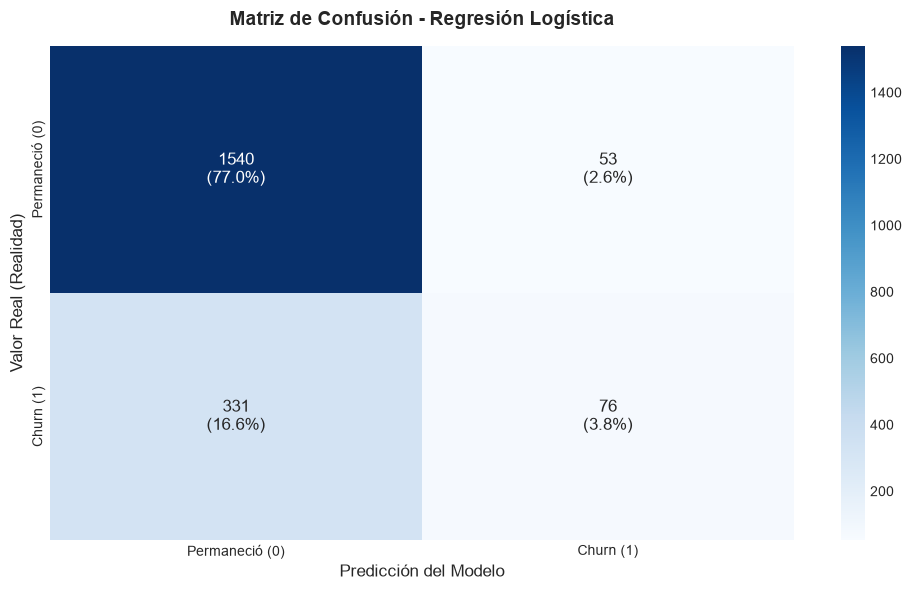

🚨 DESGLOSE DE LA MATRIZ DE CONFUSIÓN:
----------------------------------------------------------------------------------------------------
❗❗Falsos Negativos    (FN):  331 (Fugas no detectadas - ERROR GRAVE)
⭕ Falsos Positivos      (FP):   53 (Falsas alarmas de churn)
✅ Verdaderos Negativos  (TN): 1540 (Clientes retenidos predichos correctamente)
✅ Verdaderos Positivos  (TP):   76 (Clientes en churn detectados a tiempo)


In [18]:
# Evaluación del modelo
# Usando Matriz de Confusión / Curva ROC y AUC / Precision - Recall - F1-Score

# Sacamos nuestras predicciones del modelo:
y_pred = modelo_rl.predict(x_test_scaled)                   # Predicciones binarias (0 o 1)
y_pred_proba = modelo_rl.predict_proba(x_test_scaled)[:,1]  # Probabilidades de churn

# Calculamos la Matriz de Confusión:
mc = confusion_matrix(y_test, y_pred)

# Agrego etiquetas con Conteo + Porcentaje en 1 sola línea
labels = [f'{val}\n({pct:.1f}%)' for val, pct in zip(mc.flatten(), mc.flatten() / mc.sum() * 100) ]
labels = np.array(labels).reshape(2, 2)

# Graficamos la matriz:
plt.Figure(figsize=(7, 5))
sns.heatmap(
    mc,
    annot=labels,
    fmt='',
    cmap='Blues',
    xticklabels=['Permaneció (0)', 'Churn (1)'],
    yticklabels=['Permaneció (0)', 'Churn (1)'],
    annot_kws={'size':12},
)

plt.title('Matriz de Confusión - Regresión Logística', fontsize=14, pad=15)
plt.xlabel('Predicción del Modelo', fontsize=12)
plt.ylabel('Valor Real (Realidad)', fontsize=12)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = mc.ravel()
print("🚨 DESGLOSE DE LA MATRIZ DE CONFUSIÓN:")
print("-" * 100)
print(f"❗❗Falsos Negativos    (FN): {fn:4d} (Fugas no detectadas - ERROR GRAVE)")
print(f"⭕ Falsos Positivos      (FP): {fp:4d} (Falsas alarmas de churn)")
print(f"✅ Verdaderos Negativos  (TN): {tn:4d} (Clientes retenidos predichos correctamente)")
print(f"✅ Verdaderos Positivos  (TP): {tp:4d} (Clientes en churn detectados a tiempo)")

### ▶️ REGRESIÓN LOGÍSTICA - PARTE 9

***METRICAS EVALUADORAS RESTANTES***

📌 Interpretación de Métricas e Insights de Negocio:
- Accuracy (80.80%):
     El modelo acierta en el 80.80% de sus predicciones totales. Pero el modelo no detecta el problema real, recordemos que tenemos un Dataset desbalanceado, el 80% de los clientes no son churn. Un modelo que adivine casi siempre "no churn" obtendrá un Accuracy muy alto por inercia, sin detectar el problema real.

- Precision (58.91%):
     De cada 100 clientes que el modelo marca como en riesgo de fuga, solo, aproximadamete 59 realmente se van y 41 son falsas alarmas.

- ❌ Recall (18.67%): (Fugas no detectadas, el verdadero problema)
     De cada 100 clientes que realmente son churn, el modelo solo logra detectar aproximadamente 19. El 81.33% NO estan siendo detectados.

- F1-Score (28.36%):
     El F1-Score mide la armonia entre Precision y Recall. Combina ambas métricas en un solo número para medir qué tan equilibrado es el modelo. Para éste modelo, el 28.36% nos indica que esta siendo arrastrado hacia abajo por un Recall tan bajo, confirmando estadísticamente que el modelo actual no está bien balanceado para detectar churn.

- CURVA ROC y AUC (77.48%):
     Mide la capacidad y/o potencia general del modelo para distinguir entre un cliente churn y no churn. Un 77.48% es bastante bueno. Ya que nos indica que los coeficientes y las variables sí aprendieron patrones reales.

🔎 RESUMEN DE MÉTRICAS DE EVALUACIÓN:
----------------------------------------------------------------------------------------------------
- Accuracy (Exactitud)   : 0.8080 (80.80%)
- Precision (Precisión)  : 0.5891 (58.91%)
- Recall (Sensibilidad)   : 0.1867 (18.67%)
- F1-Score               : 0.2836 (28.36%)
- ROC - AUC              : 0.7748 (77.48%)
----------------------------------------------------------------------------------------------------


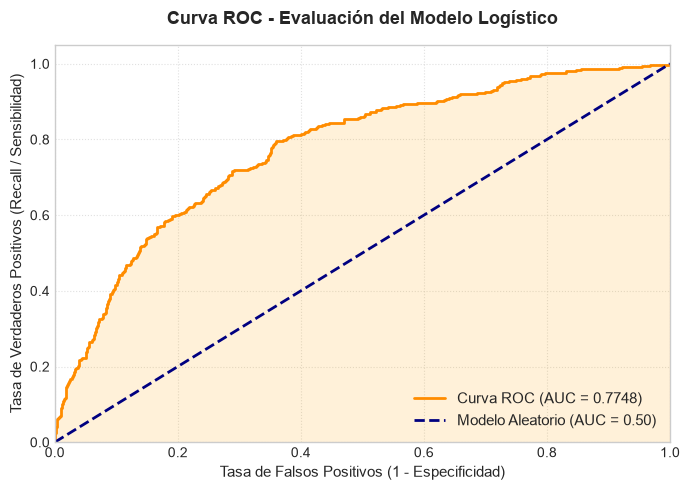

In [19]:
# Realizamos la medición del accuracy utilizando sklearn:
# Ya contamos con nuestra probabilidad predicha por clase (Chur = 1)
# Bajo la variable: y_pred_proba = modelo_rl.predict_proba(x_test_scaled)[:,1] 

# 1. Calculamos los puntos de la Curva ROC y AUC (área debajo de la curva) y Accuracy 
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Mostramos los resulados del accuracy
print("🔎 RESUMEN DE MÉTRICAS DE EVALUACIÓN:")
print("-" * 100)
print(f"- Accuracy (Exactitud)   : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"- Precision (Precisión)  : {precision:.4f} ({precision*100:.2f}%)")
print(f"- Recall (Sensibilidad)   : {recall:.4f} ({recall*100:.2f}%)")
print(f"- F1-Score               : {f1:.4f} ({f1*100:.2f}%)")
print(f"- ROC - AUC              : {roc_auc:.4f} ({roc_auc*100:.2f}%)")
print("-" * 100)

# Graficamos nuestra curva:

plt.figure(figsize=(7, 5))
plt.plot(
    fpr,
    tpr,
    color= 'darkorange',
    lw=2,
    label=f'Curva ROC (AUC = {roc_auc:.4f})',
)
plt.fill_between(fpr, tpr, color='orange', alpha=0.15)
plt.plot(
    [0, 1],
    [0, 1],
    color='navy',
    lw=2,
    linestyle='--',
    label='Modelo Aleatorio (AUC = 0.50)'
)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)', fontsize=11)
plt.ylabel('Tasa de Verdaderos Positivos (Recall / Sensibilidad)', fontsize=11)
plt.title('Curva ROC - Evaluación del Modelo Logístico', fontsize=13, pad=15)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

### ▶️ CONCLUSIÓN REGRESIÓN LOGÍSTICA - PARTE 10

***Conclusión de nuestro modelo de regresión logistica***

Contamos con un modelo robusto, que fue capaz de aprender sobre los datos de entrenamiento (x_train y y_train) y realizar predicciones cercanas a la realidad.

Tiene un buen porcentaje (80%) de **Accuracy** y un porcentaje superior al 0.50% en **Precision**, sin embargo, en la practica esta dejando filtrar aproximadamente el 80% de los clientes churn. Esto es posible debido a su bajo porcentaje en **Recall** (18%) y su F1-Score (28%).

### La sugerencia en el caso de éste modelo, sería complementarlo con otros modelos de supervisión, o realizar un conjunto de modelos de supervisión robusto que trabajen en conjunto y "aprendan" de errores. La finalidad seria llegar a obtener un porcentaje de detección de posibles clientes churn en la realiadad mayor al 90%

### Guardando datos bases de mi modelo.
Se va a realizar el entrenamiento de multiples modelos en un nuevo notebook, esto con el fin de buscar un modelo o conjunto de modelos que puedan trabajar entre si y brindar un resultado más optimo (por lo menos cerca a 85%)

Para ésto se realizará la exportación de las variables en formato CSV, y a su vez, se cargaran los datos, se realizará proceso de validación para confirmar que los datos son correctos, se entrenará de nuevo el modelo de Regresión Logistica y se confirmará que los datos son exactos a los de éste documento.

In [20]:
print(f"🔄️ Exportando mis variables a un Archivo CVS...")
#x_train_scaled.to_csv("../data/x_train_scaled.csv", index=False)
#x_test_scaled.to_csv("../data/x_test_scaled.csv", index=False)
#y_train.to_csv("../data/y_train.csv", index=False)
#y_test.to_csv("../data/y_test.csv", index=False)

print(f"¡Archivos exportados exitosamente!")
print(f"🚀 Listos para empezar Avance 2 de éste Gran Proyecto!")

# ----------------------------------------------------------------------------

print("-"*100)
print(f"Exportando mi DataFrame final Codificado a un archivo CSV para su posterior uso en el avance 3")
print("Confirmando estado de mi Dataframe:...")
display(df_copy.head())
print("\nExportando archivo CSV...")
#df_copy.to_csv("../data/Churn_modelling_Encoder.csv", index=False)
print("✅ Archivo exportado correctamente Para el Avance 3 del proyecto. ¡Listo para continuar!")

🔄️ Exportando mis variables a un Archivo CVS...
¡Archivos exportados exitosamente!
🚀 Listos para empezar Avance 2 de éste Gran Proyecto!
----------------------------------------------------------------------------------------------------
Exportando mi DataFrame final Codificado a un archivo CSV para su posterior uso en el avance 3
Confirmando estado de mi Dataframe:...


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True



Exportando archivo CSV...
✅ Archivo exportado correctamente Para el Avance 3 del proyecto. ¡Listo para continuar!
